In [1]:
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import numpy as np
from jaxtyping import Array, Float

from snnax import (
    SpikingNeuralNet,
    plottable_paths,
)

key = jr.PRNGKey(12345)

## Simple LIF neuron with stochastic firing 

Let us first define all the necessary parameters which we can always change later.

In [2]:
key = jr.PRNGKey(1234)
key, init_key, dat_key, scales_key = jr.split(key, 4)
snn_init_params = {
    "num_neurons": 1,
    "v_reset": 1.4,  # Amount to reset voltage to after a spike
    "alpha": 3e-2,  # Variable controlling refractory period
    "w": jnp.array([[0.0]]),  # Weight matrix (trivial in the case of a single neuron)
    "network": jnp.array([[True]]),
    "mu": np.array([10, 0.0]),  # Variable in LIF drift term
    "sigma": jnp.array([[0.5, 0.0], [0.0, 0.0]]),  # Diffusion matrix
    "key": init_key,
    "diffusion": False,  # Whether to include diffusion in the LIF SDE
}
snn_call_params = {
    "t0": 0,
    "t1": 2,
    "max_spikes": 10,  # Maximum number of spikes allowed
    "num_samples": 10,  # Number of samples to generate
    "num_save": 1000,  # Number of time points to save per spike
    "key": dat_key,
    "dt0": 1e-2,
}
extra_params = {
    "c": 1.2,  # Input current
    "tau_s": 1,  # Variable in intensity function
    "beta": 20,  # Varibale in intensity function
    "v_th": 1,  # Spike treshold
}

We can then initialize the `SpikingNeuralNet` class which is the main model class in this library. We also define `intensity_fn` which is the intensity function used for modelling the Poisson process that governs the stochastic spike triggering. We chose the simple exponential function $v\mapsto \exp(\beta (v - v_{th})) / \tau_s$. Here $\beta, v_{th}, \tau_s$ are parameters.

In [3]:
# Intensity function for spike triggering
def intensity_fn(v: Float) -> Float:
    return jnp.exp(extra_params["beta"] * (v - extra_params["v_th"])) / extra_params["tau_s"]


# Initialize SNN
snn = SpikingNeuralNet(
    **snn_init_params,
    intensity_fn=intensity_fn,
)

We can then sample trajectories from the SNN with the given parameters for a specific input current simply by calling `snn`. A single sample trajectory is plotted below. We plot the trajectories of the neuronal state using the `plottable_paths` helper function. (*Note: The orange line is the internal input current of the neuron aggregating the spikes from pre-synpatic neurons. In this case it is constantly equal to 0 since we are only considering a single neuron. This is different from the external input current which is given by the function `input_current`.*) 

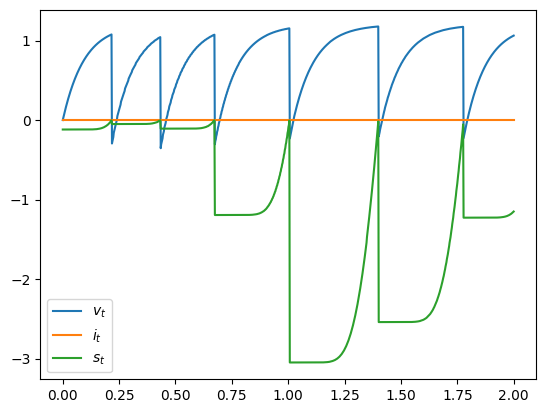

In [4]:
# Input current
def input_current(t: Float) -> Array:
    return jnp.array([extra_params["c"]])


# Set initial conditions
snn_call_params["v0"] = np.full((snn_call_params["num_samples"], snn_init_params["num_neurons"]), 0)
snn_call_params["i0"] = np.full((snn_call_params["num_samples"], snn_init_params["num_neurons"]), 0)

# Generate forward passes
sol = snn(input_current, **snn_call_params)

# Plot interanl state of neuron
ts_plt, ys_plt = plottable_paths(sol)
plt.plot(ts_plt[4], ys_plt[4, 0, :, 0], label="$v_t$")
plt.plot(ts_plt[4], ys_plt[4, 0, :, 1], label="$i_t$")
plt.plot(ts_plt[4], ys_plt[4, 0, :, 2], label="$s_t$")
plt.legend();

## Stochastic LIF neuron

We can add a diffusion term to the inter-event differential equation. This yields a neuron model with two sources of noise: 1) the noise in the stochastic firing and the noise perturbing the inter-event dynamics (given by the Brownian control). 

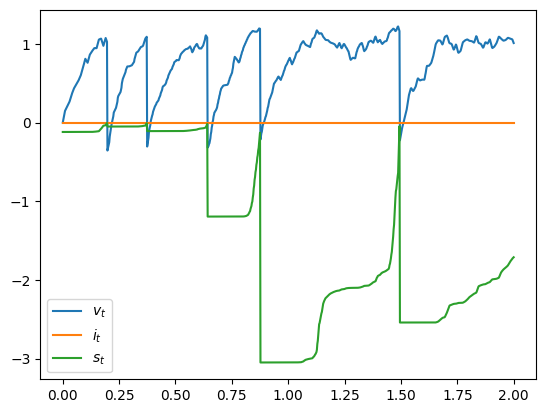

In [6]:
# Add diffusion
snn_init_params["diffusion"] = True

# Initialize SNN
ssnn = SpikingNeuralNet(
    **snn_init_params,
    intensity_fn=intensity_fn,
)

# Generate forward passes
sol = ssnn(input_current, **snn_call_params)

# Plot interanl state of neuron
ts_plt, ys_plt = plottable_paths(sol)
plt.plot(ts_plt[4], ys_plt[4, 0, :, 0], label="$v_t$")
plt.plot(ts_plt[4], ys_plt[4, 0, :, 1], label="$i_t$")
plt.plot(ts_plt[4], ys_plt[4, 0, :, 2], label="$s_t$")
plt.legend();